In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
# torchvision.datasets -> get datasets and dataloaders for cv 
# torchvision.models -> get pretrained models for cv
# torchvision.transforms -> get functions for manipulating your vision data

In [3]:
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [4]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [5]:
# getting a dataset
# we will be loading fashionMNIST dataset from torchvision.datasets
training_data = datasets.FashionMNIST(
    root="data", # where to download the data
    train=True, # do we want the training dataset? if not, we get the test dataset
    download=True, # do we want to download the data if it doesn't exist in root?
    transform=transforms.ToTensor(), # transform the data to a PyTorch tensor,
    target_transform=None # how do we want to transform the labels? (we don't want to do anything with them so we set it to None)
)

testing_data= datasets.FashionMNIST(
    root="data",
    train=False, # do we want the training dataset? if not, we get the test dataset
    download=True, # do we want to download the data if it doesn't exist in root?
    transform=transforms.ToTensor(), # transform the data to a PyTorch tensor,
    target_transform=None # how do we want to transform the labels? (we don't want to do anything with them so we set it to None)
)



100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.9MB/s]


In [6]:
training_data, testing_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [7]:
# see the first training data
image,label = training_data[0]
print(f"Image shape: {image.shape}->[color channel, height, width] | Label: {label}")
print(f"image label name : {training_data.classes[label]}")

Image shape: torch.Size([1, 28, 28])->[color channel, height, width] | Label: 9
image label name : Ankle boot


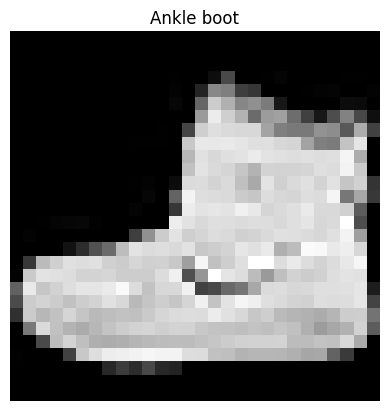

In [8]:
# visualizing our data
plt.imshow(image.squeeze(), cmap="gray")
plt.title(training_data.classes[label])
plt.axis(False)
plt.show()

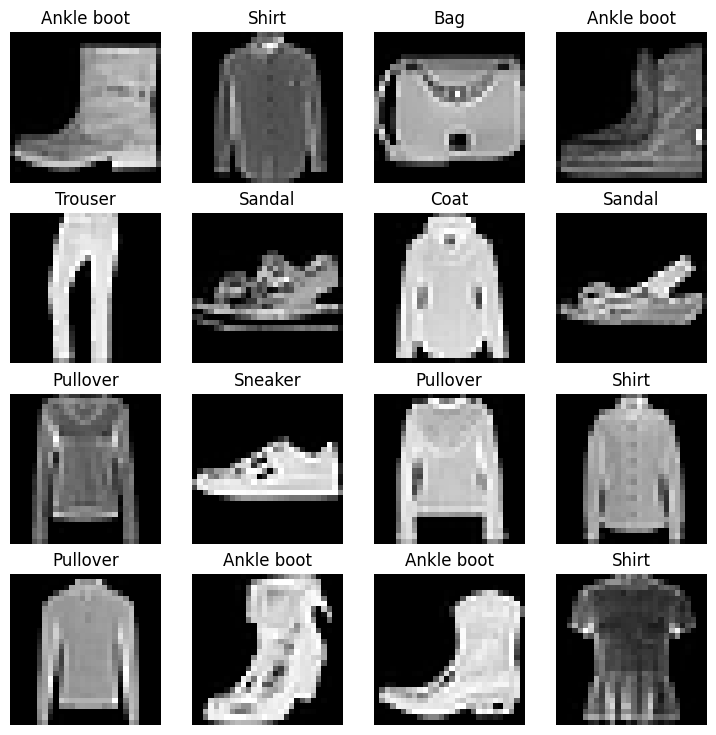

In [9]:
fig=plt.figure(figsize=(9,9))
rows,cols = 4,4
torch.manual_seed(42) # set the random seed for reproducibility
for i in range(1,rows*cols+1):
    random_idx = torch.randint(0,len(training_data),size=[1]).item()
    img,label = training_data[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze(),cmap="gray")
    plt.title(training_data.classes[label])
    plt.axis(False)

In [10]:
# prepare dataloaders
# dataloader turns datasets into python iterables 
# morespecifially we can use dataloaders to load our data in batches, shuffle the data and load the data in parallel using multiprocessing workers

In [11]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle=False)


In [12]:
print(f"Number of batches in training dataloader: {len(train_dataloader)}")
print(f"Number of batches in testing dataloader: {len(test_dataloader)}")

Number of batches in training dataloader: 1875
Number of batches in testing dataloader: 313


In [13]:
train_features_batch,train_labels_batch=next(iter(train_dataloader))
print(f"Feature batch shape: {train_features_batch.size()} | Labels batch shape: {train_labels_batch.size()}")

Feature batch shape: torch.Size([32, 1, 28, 28]) | Labels batch shape: torch.Size([32])


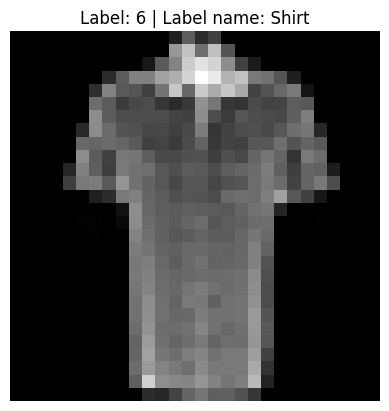

In [14]:
# show a sample
torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch),size=[1]).item()
img,label = train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.axis(False)
plt.title(f"Label: {label} | Label name: {training_data.classes[label]}")
plt.show()

In [15]:
# build a model with baseline architecture : start simple then add complexity
flatten_model = nn.Flatten()

x=train_features_batch[0]
output = flatten_model(x)
print(f"Shape of input batch: {x.shape} | Shape of output batch: {output.shape}")

Shape of input batch: torch.Size([1, 28, 28]) | Shape of output batch: torch.Size([1, 784])


In [16]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape:int, hidden_units:int, output_shape:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)

In [17]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [18]:
torch.manual_seed(42)
# setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=28*28, hidden_units=10, output_shape=len(training_data.classes)).to(device)
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [19]:
# we have our data and our model, now we need to setup a loss function and an optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [20]:
# train the model
from tqdm.auto import tqdm
torch.manual_seed(42)
EPOCHS = 3
for epoch in tqdm(range(EPOCHS)):
    # training
    model_0.train()
    train_loss = 0
    for batch, (X,y) in enumerate(train_dataloader):
        X,y = X.to(device),y.to(device)
        y_pred = model_0(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss /= len(train_dataloader)
    # testing
    model_0.eval()
    with torch.inference_mode():
        test_loss, correct, total = 0,0,0
        for X,y in test_dataloader:
            X,y = X.to(device),y.to(device)
            test_pred = model_0(X)
            test_loss += loss_fn(test_pred,y).item()
            correct += (test_pred.argmax(1) == y).sum().item()
            total += y.size(0)
        test_loss /= len(test_dataloader)
        test_acc = correct/total
    print(f"epoch: {epoch} | train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch: 0 | train_loss: 0.5904 | test_loss: 0.5095 | test_acc: 0.8203
epoch: 1 | train_loss: 0.4763 | test_loss: 0.4799 | test_acc: 0.8318
epoch: 2 | train_loss: 0.4550 | test_loss: 0.4766 | test_acc: 0.8341


In [21]:
# evaluating
torch.manual_seed(42)
model_0.eval()
with torch.inference_mode():
    test_loss, correct, total = 0,0,0
    for X,y in test_dataloader:
        X,y = X.to(device),y.to(device)
        test_pred = model_0(X)
        test_loss += loss_fn(test_pred,y).item()
        correct += (test_pred.argmax(1) == y).sum().item()
        total += y.size(0)
    test_loss /= len(test_dataloader)
    test_acc = correct/total
print(f"test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

test_loss: 0.4766 | test_acc: 0.8341


In [22]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [23]:
#  building a model 1 with non linearity
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape:int, hidden_units:int, output_shape:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)

In [24]:
model_1= FashionMNISTModelV1(input_shape=28*28, hidden_units=10, output_shape=len(training_data.classes)).to(device)
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
    (5): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [25]:
# loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [26]:
# define the training loop
EPOCHS = 3
for epoch in tqdm(range(EPOCHS)):
    model_1.train()
    train_loss = 0
    for batch, (X,y) in enumerate(train_dataloader):
        X,y = X.to(device),y.to(device)
        y_pred = model_1(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss /= len(train_dataloader)
    # testing   
    model_1.eval()
    with torch.inference_mode():
        test_loss, correct, total = 0,0,0
        for X,y in test_dataloader:
            X,y = X.to(device),y.to(device)
            test_pred = model_1(X)
            test_loss += loss_fn(test_pred,y).item()
            correct += (test_pred.argmax(1) == y).sum().item()
            total += y.size(0)
        test_loss /= len(test_dataloader)
        test_acc = correct/total
    print(f"epoch: {epoch} | train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch: 0 | train_loss: 0.6809 | test_loss: 0.5081 | test_acc: 0.8161
epoch: 1 | train_loss: 0.4804 | test_loss: 0.4986 | test_acc: 0.8224
epoch: 2 | train_loss: 0.4414 | test_loss: 0.4570 | test_acc: 0.8379


In [27]:
# get model 1 in results dictionary
model_1_results = {"model_name": model_1.__class__.__name__,
                   "model_loss": test_loss,
                   "model_acc": test_acc}
model_1_results


{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.45704277283467426,
 'model_acc': 0.8379}

## Buiding CNN

In [29]:
class FashionMNISTModel_CNN(nn.Module):
    def __init__(self, input_shape:int, hidden_units:int, output_shape:int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
        )
    
    def forward(self,x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

In [33]:
model_cnn= FashionMNISTModel_CNN(input_shape=28*28, hidden_units=10, output_shape=len(training_data.classes)).to(device)
output_shape = len(training_data.classes)
output_shape

10

In [37]:
# loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_cnn.parameters(), lr=0.1)

# train the model
from tqdm.auto import tqdm
torch.manual_seed(42)
EPOCHS = 3
for epoch in tqdm(range(EPOCHS)):
    # training
    model_cnn.train()
    train_loss = 0
    for batch, (X,y) in enumerate(train_dataloader):
        X,y = X.to(device),y.to(device)
        y_pred = model_cnn(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss /= len(train_dataloader)
    # testing
    model_cnn.eval()
    with torch.inference_mode():
        test_loss, correct, total = 0,0,0
        for X,y in test_dataloader:
            X,y = X.to(device),y.to(device)
            test_pred = model_cnn(X)
            test_loss += loss_fn(test_pred,y).item()
            correct += (test_pred.argmax(1) == y).sum().item()
            total += y.size(0)
        test_loss /= len(test_dataloader)
        test_acc = correct/total
    print(f"epoch: {epoch} | train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch: 0 | train_loss: 0.2807 | test_loss: 0.3075 | test_acc: 0.8931
epoch: 1 | train_loss: 0.2740 | test_loss: 0.2972 | test_acc: 0.8932
epoch: 2 | train_loss: 0.2689 | test_loss: 0.3040 | test_acc: 0.8930


In [59]:
model_cnn.eval()
with torch.inference_mode():
    test_loss, correct, total = 0,0,0
    count=0
    y_test_pred=[]
    for X,y in tqdm(test_dataloader):
        count+=1
        X,y = X.to(device),y.to(device)
        y_logits= model_cnn(X)
        y_pred= torch.softmax(y_logits, dim=1).argmax(1)
        test_loss += loss_fn(y_logits,y).item()
        correct += (y_pred == y).sum().item()
        total += y.size(0)
        y_test_pred.extend(y_pred)
    test_loss /= len(test_dataloader)
    test_acc = correct/total
print(f"test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

  0%|          | 0/313 [00:00<?, ?it/s]

test_loss: 0.3040 | test_acc: 0.8930


/tmp/ipykernel_4702/1835929785.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  confmat_tensor = confmat(preds=torch.tensor(y_test_pred), target=torch.tensor(testing_data.targets))


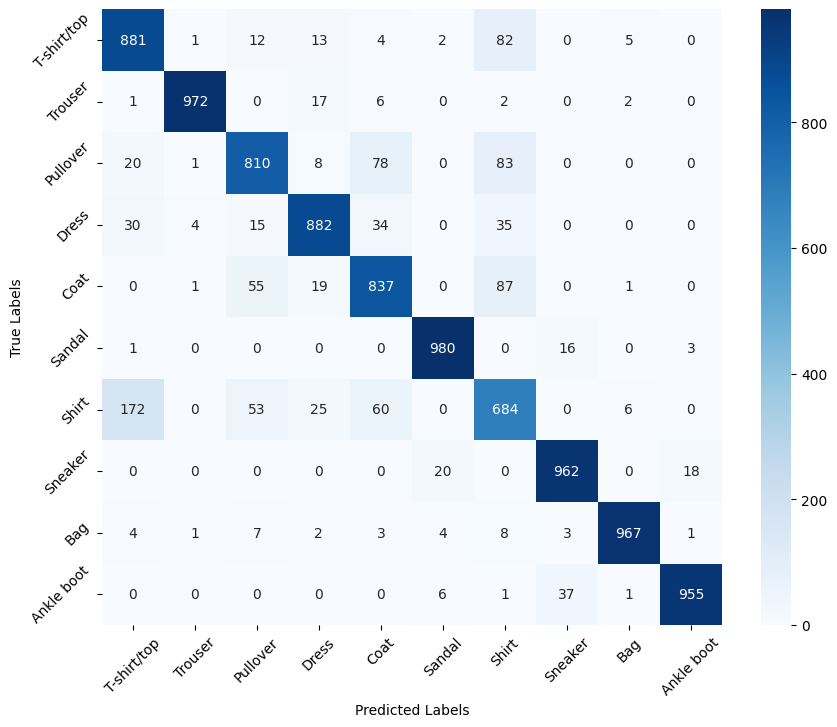

In [73]:
from torchmetrics import ConfusionMatrix
confmat = ConfusionMatrix(num_classes=len(training_data.classes),task="multiclass")
confmat_tensor = confmat(preds=torch.tensor(y_test_pred), target=torch.tensor(testing_data.targets))
# plotting confusion matrix
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(confmat_tensor, annot=True, fmt='d', cmap='Blues', xticklabels=training_data.classes, yticklabels=training_data.classes)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [63]:
# !pip install torchmetrics

In [74]:
# saving the model and reloading
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME="fashion_mnist_model_cnn.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# save the model state dict
torch.save(obj=model_cnn.state_dict(), f=MODEL_SAVE_PATH)

In [79]:
# loading 
cnn_model_loaded= FashionMNISTModel_CNN(input_shape=28*28, hidden_units=10, output_shape=len(training_data.classes)).to(device)
cnn_model_loaded.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [80]:
cnn_model_loaded.eval()
with torch.inference_mode():
    test_loss, correct, total = 0,0,0
    count=0
    y_test_pred=[]
    for X,y in tqdm(test_dataloader):
        count+=1
        X,y = X.to(device),y.to(device)
        y_logits= model_cnn(X)
        y_pred= torch.softmax(y_logits, dim=1).argmax(1)
        test_loss += loss_fn(y_logits,y).item()
        correct += (y_pred == y).sum().item()
        total += y.size(0)
        y_test_pred.extend(y_pred)
    test_loss /= len(test_dataloader)
    test_acc = correct/total
print(f"test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

  0%|          | 0/313 [00:00<?, ?it/s]

test_loss: 0.3040 | test_acc: 0.8930


/tmp/ipykernel_4702/1835929785.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  confmat_tensor = confmat(preds=torch.tensor(y_test_pred), target=torch.tensor(testing_data.targets))


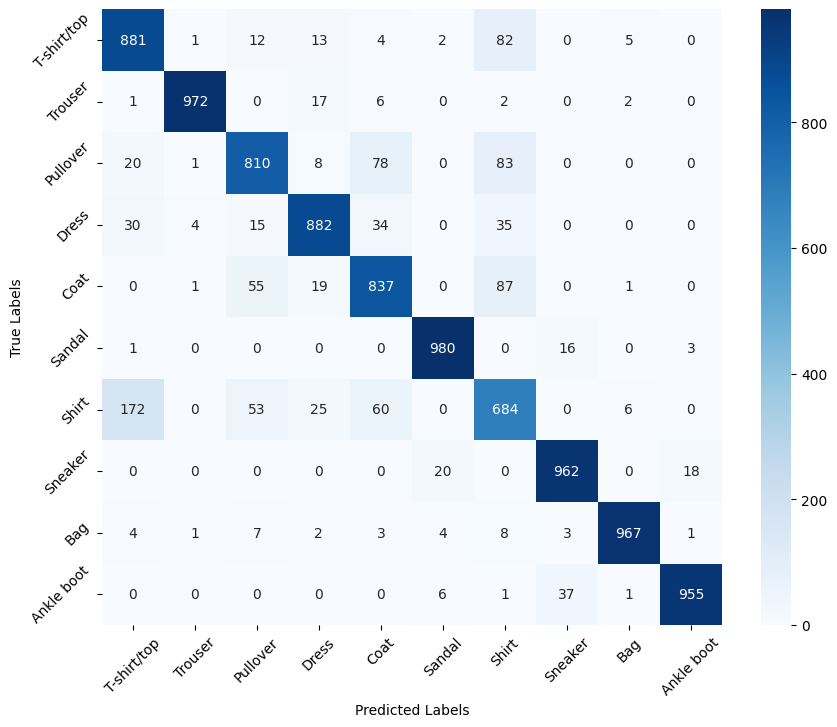

In [81]:
from torchmetrics import ConfusionMatrix
confmat = ConfusionMatrix(num_classes=len(training_data.classes),task="multiclass")
confmat_tensor = confmat(preds=torch.tensor(y_test_pred), target=torch.tensor(testing_data.targets))
# plotting confusion matrix
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(confmat_tensor, annot=True, fmt='d', cmap='Blues', xticklabels=training_data.classes, yticklabels=training_data.classes)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()